# Telco Customer Churn Prediction
**Business objective:** identify customers at risk of leaving so the retention team can prioritize outreach.

**Target:** `Churn`, Yes = 1 and No = 0. **Model:** Decision Tree Classifier.

Run every cell on your actual CSV, review the generated findings, and save this notebook with its outputs before submission. This template contains no claimed dataset results. All numbers and chart insights are computed when executed.

We reserve 30% for a final test, use seed 42, and compare four tree configurations using cross-validation only within the remaining 70%. Recall is a business priority; selection uses F2 to emphasize recall while still penalizing false positives. This is a stated assumption because retention costs and campaign capacity were not supplied.

## 1. Setup and dataset loading
Place the actual customer records in `data/telco_churn.csv`. Change `DATA_PATH` below if needed. Use the CSV dataset, not the data dictionary.

In [1]:
from pathlib import Path
import sys, os, json, hashlib, platform
from datetime import datetime, timezone
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, make_scorer, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.dummy import DummyClassifier
from sklearn.tree import plot_tree, export_text

ROOT = Path.cwd().resolve()
if not (ROOT / "preprocessing.py").exists():
    ROOT = ROOT.parent
if not (ROOT / "preprocessing.py").exists():
    raise FileNotFoundError("Open this notebook from the project root or its notebook folder.")
sys.path.insert(0, str(ROOT))
from preprocessing import RAW_FEATURES, NUMERIC, CATEGORIES, TelcoFeatures, clean_features, make_pipeline, prediction_result

DATA_PATH = Path(os.environ.get("CHURN_DATA_PATH", str(ROOT / "data/telco_churn.csv")))
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
(ROOT / "model").mkdir(exist_ok=True)
SEED = 42
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 30)

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Copy your customer CSV to {DATA_PATH}, or edit DATA_PATH above.")
raw = pd.read_csv(DATA_PATH)
raw.columns = raw.columns.str.strip()
if raw.columns.duplicated().any():
    raise ValueError("Duplicate column names after trimming; correct the CSV headers.")
required = set(RAW_FEATURES + ["customerID", "Churn"])
if not required.issubset(raw.columns):
    raise ValueError(f"Missing columns: {sorted(required - set(raw.columns))}. Did you load the data dictionary?")
print("Dataset shape:", raw.shape)
display(raw.head())
raw.info()
print("Extra columns excluded from modeling:", sorted(set(raw.columns) - required))

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data understanding, quality checks and preparation
- Report source dtypes, missing/blank values and numeric values that cannot be parsed.
- Trim whitespace and normalize known categorical values. `No internet service` is a valid category, not a missing value.
- Convert numeric strings, including `TotalCharges`; blanks, nonnumeric entries and infinities become missing and are reported. Review parse failures before submission; if they reveal a source problem, correct it and rerun.
- Remove exact duplicate customer records after normalization. If a customer ID still appears more than once, stop for review rather than split the same customer across train/test.
- Do not invent missing target labels or use `customerID` as a predictor. Unknown columns are excluded, avoiding accidental use of outcome-related fields.
- Fit numeric median imputation and categorical encoding only inside the training pipeline. No scaling is needed for a Decision Tree. All-empty numeric training columns use the imputer's zero fallback; missing categories have their own `Missing` category.

In [2]:
quality = pd.DataFrame({"source_dtype": raw.dtypes.astype(str), "missing_raw": raw.isna().sum()})
quality["blank_strings"] = [raw[c].map(lambda x: isinstance(x, str) and not x.strip()).sum() for c in raw]
quality["unparseable_or_nonfinite_numeric"] = 0
for c in NUMERIC:
    nonblank = raw[c].notna() & raw[c].astype(str).str.strip().ne("")
    parsed = pd.to_numeric(raw[c], errors="coerce")
    quality.loc[c, "unparseable_or_nonfinite_numeric"] = int((nonblank & ~np.isfinite(parsed)).sum())
cleaned = clean_features(raw)
quality["missing_after_cleaning"] = cleaned.isna().sum().reindex(quality.index)
display(quality)
quality.to_csv(REPORTS / "data_quality.csv")

ids = raw["customerID"].astype("string").str.strip()
if ids.isna().any() or ids.eq("").any():
    raise ValueError("Missing customerID: correct or explicitly resolve these records before splitting.")
target = raw["Churn"].astype("string").str.strip().str.casefold().map({"yes": 1, "no": 0})
if target.isna().any():
    raise ValueError("Churn has missing/invalid values. Expected Yes or No for every training row.")

data = cleaned.copy()
data.insert(0, "customerID", ids)
data["Churn"] = target.astype(int)
raw_duplicates = int(raw.duplicated().sum())
normalized_duplicates = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
repeated_ids = data["customerID"].duplicated(keep=False)
print(f"Raw exact duplicates: {raw_duplicates}; normalized duplicate rows removed: {normalized_duplicates}")
print(f"Rows with repeated customer IDs after deduplication: {repeated_ids.sum()}")
if repeated_ids.any():
    display(data.loc[repeated_ids].head(10))
    raise ValueError("Multiple distinct records for a customer. Resolve their meaning before a customer-level split.")
if data["Churn"].nunique() != 2:
    raise ValueError("Both Yes and No target classes are required.")
print("Numeric features:", NUMERIC)
print("Categorical features:", list(CATEGORIES))
print("SeniorCitizen is a binary indicator retained as numeric.")
display(data[NUMERIC].describe())
display(data[list(CATEGORIES)].nunique().rename("unique_categories").to_frame())
display(data["Churn"].value_counts().rename(index={0: "No", 1: "Yes"}).to_frame("customers"))
print(f"Overall churn prevalence: {data['Churn'].mean():.1%}")

,source_dtype,missing_raw,blank_strings,unparseable_or_nonfinite_numeric,missing_after_cleaning
customerID,object,0,0,0,NaN
gender,object,0,0,0,0.0
SeniorCitizen,int64,0,0,0,0.0
Partner,object,0,0,0,0.0
Dependents,object,0,0,0,0.0
tenure,int64,0,0,0,0.0
PhoneService,object,0,0,0,0.0
MultipleLines,object,0,0,0,0.0
InternetService,object,0,0,0,0.0
OnlineSecurity,object,0,0,0,0.0


Raw exact duplicates: 0; normalized duplicate rows removed: 0
Rows with repeated customer IDs after deduplication: 0
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
SeniorCitizen is a binary indicator retained as numeric.


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


,unique_categories
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


,customers
Churn,
No,5174
Yes,1869


Overall churn prevalence: 26.5%


## 3. Required 70:30 split
Stratification preserves the approximate churn proportion in both subsets. Detailed EDA uses training rows only. The test set is reserved until the final configuration is selected; the earlier full-data quality checks are deterministic checks, not learned preprocessing.

In [3]:
train, test = train_test_split(data, test_size=0.30, stratify=data["Churn"], random_state=SEED)
X_train, y_train = train[RAW_FEATURES].copy(), train["Churn"].copy()
X_test, y_test = test[RAW_FEATURES].copy(), test["Churn"].copy()
assert set(train.customerID).isdisjoint(set(test.customerID))
if y_train.value_counts().min() < 5:
    raise ValueError("Need at least five training examples of each class for the planned five-fold CV.")
print(f"Training: {len(train)} rows; test: {len(test)} rows")
print(f"Training churn: {y_train.mean():.1%}; test churn: {y_test.mean():.1%}")
pd.concat([train[["customerID"]].assign(split="train"), test[["customerID"]].assign(split="test")]).to_csv(REPORTS / "split_membership.csv", index=False)
eda = X_train.copy()
eda["Churn"] = y_train.map({0: "No", 1: "Yes"})
eda["churn_flag"] = y_train
insights = []
def insight(text):
    insights.append(text)
    display(Markdown("**Business insight:** " + text))
def finish(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

Training: 4930 rows; test: 2113 rows
Training churn: 26.5%; test churn: 26.5%


## 4. Exploratory data analysis: eight visualizations
These observations describe associations in the training data. They do not demonstrate that changing an attribute will cause churn to decrease. Group sizes are shown alongside churn rates to make small segments visible.

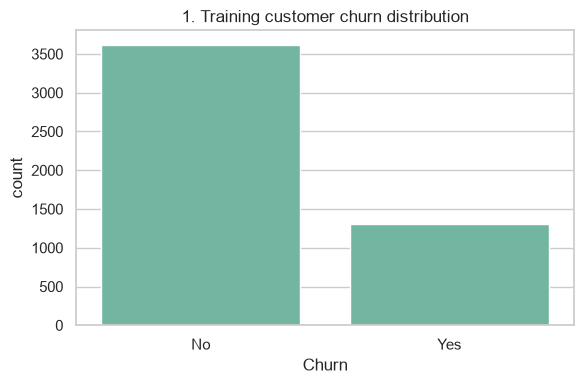

**Business insight:** 26.5% of training customers churned. Compare against a majority-class baseline; accuracy alone can hide missed churners.

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=eda, x="Churn", order=["No", "Yes"])
plt.title("1. Training customer churn distribution")
finish("01_churn_distribution")
insight(f"{y_train.mean():.1%} of training customers churned. Compare against a majority-class baseline; accuracy alone can hide missed churners.")

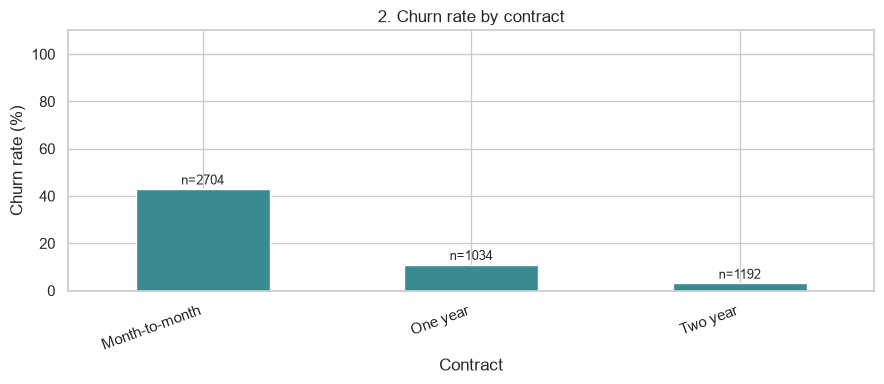

,churn_rate,customers
Contract,,
Month-to-month,0.428624,2704
One year,0.109284,1034
Two year,0.030201,1192


**Business insight:** For Contract, Month-to-month has the highest observed churn rate (42.9%, n=2704); Two year has 3.0%. Use contract segments to prioritize retention experiments and evaluate renewal support. Treat small groups cautiously.

In [5]:
def categorical_churn_plot(column, name, title, action):
    summary = eda.assign(**{column: eda[column].fillna("Missing")}).groupby(column)["churn_flag"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    ax = (100 * summary["mean"]).plot.bar(figsize=(9, 4), color="#398a91")
    ax.set(title=title, ylabel="Churn rate (%)", xlabel=column, ylim=(0, 110))
    for bar, n in zip(ax.patches, summary["count"]):
        ax.annotate(f"n={n}", (bar.get_x()+bar.get_width()/2, bar.get_height()+2), ha="center", fontsize=9)
    plt.xticks(rotation=20, ha="right")
    finish(name)
    display(summary.rename(columns={"mean": "churn_rate", "count": "customers"}))
    highest, lowest = summary.index[0], summary.index[-1]
    insight(f"For {column}, {highest} has the highest observed churn rate ({summary.loc[highest, 'mean']:.1%}, n={summary.loc[highest, 'count']}); {lowest} has {summary.loc[lowest, 'mean']:.1%}. {action} Treat small groups cautiously.")

categorical_churn_plot("Contract", "02_contract_churn", "2. Churn rate by contract",
                       "Use contract segments to prioritize retention experiments and evaluate renewal support.")

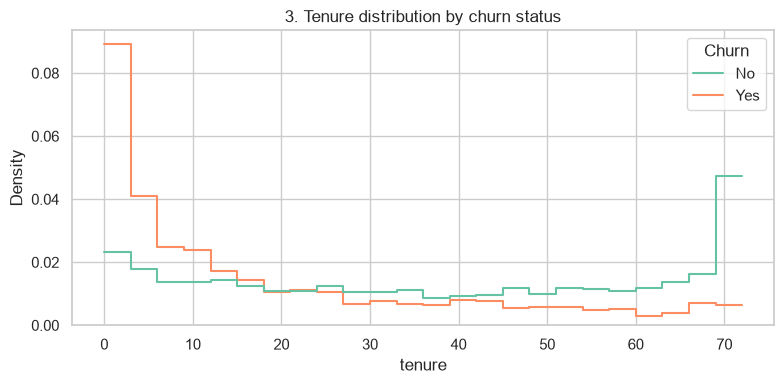

**Business insight:** Median tenure is 10.0 months for churners and 38.0 for non-churners. Use the difference to assess whether onboarding or longer-term engagement deserves attention; this is not a causal result.

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(data=eda, x="tenure", hue="Churn", hue_order=["No", "Yes"], bins=24,
             stat="density", common_norm=False, element="step", fill=False)
plt.title("3. Tenure distribution by churn status")
finish("03_tenure_distribution")
medians = eda.groupby("Churn")["tenure"].median()
insight(f"Median tenure is {medians.get('Yes', float('nan')):.1f} months for churners and {medians.get('No', float('nan')):.1f} for non-churners. Use the difference to assess whether onboarding or longer-term engagement deserves attention; this is not a causal result.")

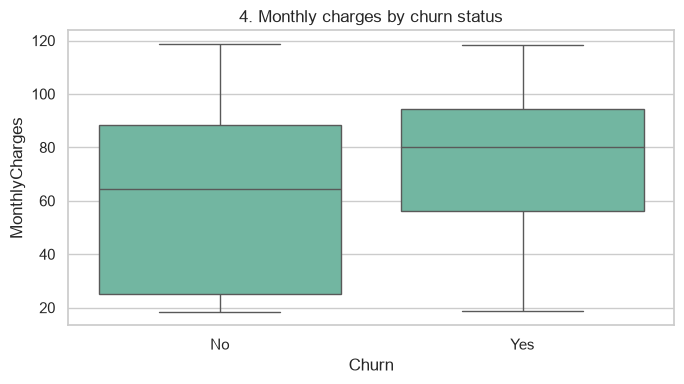

**Business insight:** Median monthly charges are 80.00 for churners versus 64.45 for non-churners (dataset currency units). Review perceived value and plan suitability rather than assuming price alone explains churn.

In [7]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda, x="Churn", y="MonthlyCharges", order=["No", "Yes"])
plt.title("4. Monthly charges by churn status")
finish("04_monthly_charges")
medians = eda.groupby("Churn")["MonthlyCharges"].median()
insight(f"Median monthly charges are {medians.get('Yes', float('nan')):.2f} for churners versus {medians.get('No', float('nan')):.2f} for non-churners (dataset currency units). Review perceived value and plan suitability rather than assuming price alone explains churn.")

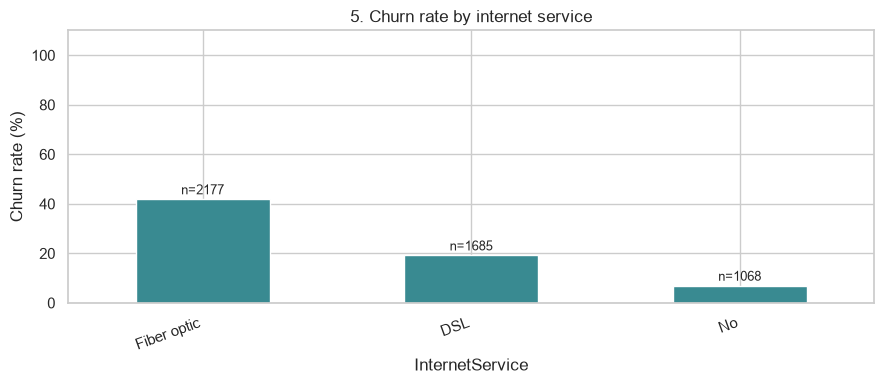

,churn_rate,customers
InternetService,,
Fiber optic,0.418466,2177
DSL,0.191691,1685
No,0.069288,1068


**Business insight:** For InternetService, Fiber optic has the highest observed churn rate (41.8%, n=2177); No has 6.9%. Investigate service experience and customer mix in the highest-rate segment before choosing an intervention. Treat small groups cautiously.

In [8]:
categorical_churn_plot("InternetService", "05_internet_churn", "5. Churn rate by internet service",
                       "Investigate service experience and customer mix in the highest-rate segment before choosing an intervention.")

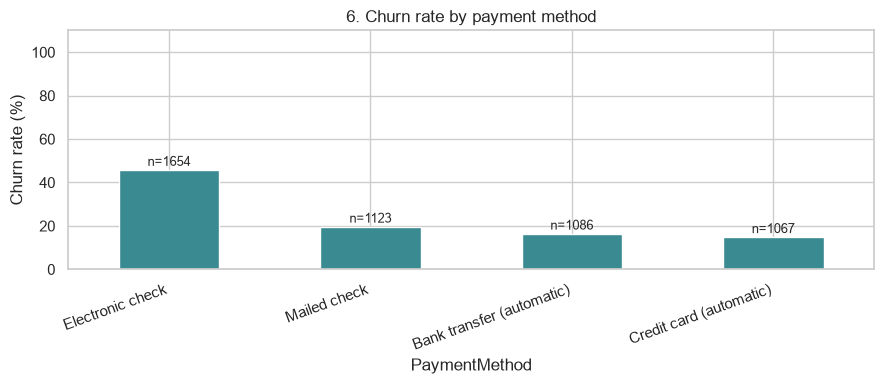

,churn_rate,customers
PaymentMethod,,
Electronic check,0.456469,1654
Mailed check,0.195013,1123
Bank transfer (automatic),0.162983,1086
Credit card (automatic),0.147142,1067


**Business insight:** For PaymentMethod, Electronic check has the highest observed churn rate (45.6%, n=1654); Credit card (automatic) has 14.7%. Review payment friction and contract mix; the payment method itself may not be the cause. Treat small groups cautiously.

In [9]:
categorical_churn_plot("PaymentMethod", "06_payment_churn", "6. Churn rate by payment method",
                       "Review payment friction and contract mix; the payment method itself may not be the cause.")

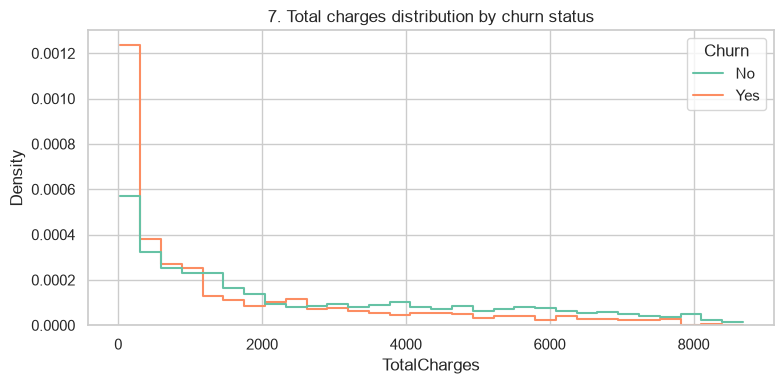

**Business insight:** Median accumulated charges are 705.08 for churners and 1679.40 for non-churners. Total charges reflect both tenure and price, so low totals should not automatically be interpreted as low customer value.

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(data=eda, x="TotalCharges", hue="Churn", hue_order=["No", "Yes"], bins=30,
             stat="density", common_norm=False, element="step", fill=False)
plt.title("7. Total charges distribution by churn status")
finish("07_total_charges")
medians = eda.groupby("Churn")["TotalCharges"].median()
insight(f"Median accumulated charges are {medians.get('Yes', float('nan')):.2f} for churners and {medians.get('No', float('nan')):.2f} for non-churners. Total charges reflect both tenure and price, so low totals should not automatically be interpreted as low customer value.")

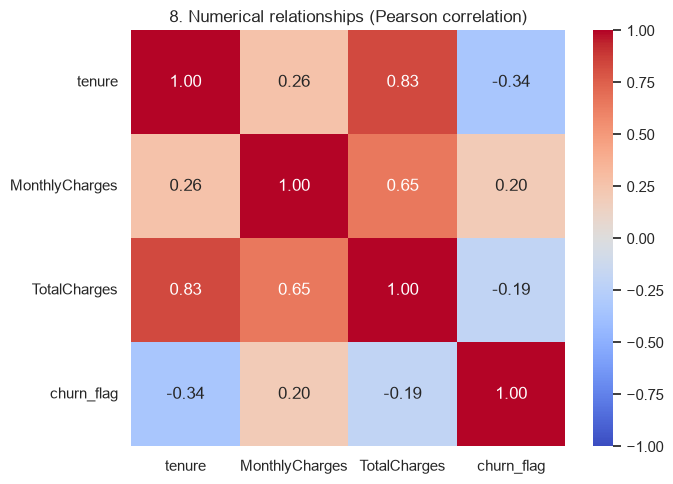

**Business insight:** Among the three continuous features, tenure has the strongest absolute linear association with churn (r=-0.34). This guides investigation but does not capture all nonlinear relationships or establish causality.

1662

In [11]:
plt.figure(figsize=(7, 5))
corr = eda[["tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("8. Numerical relationships (Pearson correlation)")
finish("08_numeric_relationships")
associations = corr["churn_flag"].drop("churn_flag").dropna()
if len(associations):
    top = associations.abs().idxmax()
    insight(f"Among the three continuous features, {top} has the strongest absolute linear association with churn (r={associations[top]:.2f}). This guides investigation but does not capture all nonlinear relationships or establish causality.")
else:
    insight("No numerical correlation can be estimated because these columns are missing or constant; resolve this data limitation before relying on numeric relationships.")
(REPORTS / "eda_insights.md").write_text("# Training-data EDA insights\n\n" + "\n\n".join(insights), encoding="utf-8")

## 5. Feature engineering and reusable preprocessing
| Feature | Construction | Potential business value |
|---|---|---|
| `TenureGroup` | Fixed bands: 0–12, 13–24, 25–48, 49+ months | Represents stages of the customer lifecycle and may simplify splits. A tree can already split tenure, so improvement is not guaranteed. |
| `ServiceCount` | Counts phone service, internet service and six active internet add-ons; range 0–8 | Represents breadth of service adoption, which may capture engagement or bundle complexity. Multiple lines are not counted as another service. |

If tenure is missing, its group is `Missing`. If any component of the service count is unknown, the count is missing and is imputed using the training median. These rules are target-independent and apply to unseen customers. Features may help; no uplift is claimed without an ablation comparison.

`preprocessing.py` contains the custom transformer so the saved model can be imported by a separate API process. The saved pipeline includes cleaning → engineering → imputation/one-hot encoding → classifier. Known categorical values absent during training are handled by `handle_unknown="ignore"`. Values outside the data dictionary are rejected.

In [12]:
engineered = TelcoFeatures().fit_transform(X_train)
display(engineered[["tenure", "TenureGroup", "PhoneService", "InternetService", "ServiceCount"]].head(10))
print("Final engineered feature columns:", engineered.columns.tolist())

,tenure,TenureGroup,PhoneService,InternetService,ServiceCount
5557,5.0,0-12 months,Yes,Fiber optic,3.0
2270,3.0,0-12 months,Yes,Fiber optic,4.0
6930,3.0,0-12 months,Yes,Fiber optic,2.0
2257,60.0,49+ months,Yes,DSL,6.0
898,12.0,0-12 months,Yes,Fiber optic,6.0
3828,65.0,49+ months,Yes,No,1.0
2147,18.0,13-24 months,Yes,No,1.0
3149,8.0,0-12 months,Yes,DSL,5.0
5401,31.0,25-48 months,Yes,No,1.0
2062,66.0,49+ months,Yes,No,1.0


Final engineered feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'ServiceCount']


## 6. Model development and comparison
Compare four specified configurations using five stratified folds within the 70% training partition:
1. Unrestricted baseline tree.
2. Shallow tree: depth 4, minimum leaf 20.
3. Regularized tree: depth 6, minimum leaf 20.
4. The same regularized tree with balanced class weights.

This is a small, explicit hyperparameter search. Balanced weights give minority-class errors more influence, and are recalculated within each training fold. No resampling is performed before the split.

Select the highest mean validation F2 score, not the best test score. F2 gives recall more weight than precision but prevents an unconstrained recall-only objective. Report F1 and the other required metrics as well. The train-to-validation gap and standard deviations help assess overfitting and instability. Tied F2 means follow candidate order, not test performance.

,configuration,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_f2,cv_f2_std,train_f2,train_validation_f2_gap,parameters
3,Regularized balanced,0.734077,0.499190,0.762221,0.603251,0.689524,0.016348,0.744919,0.055395,"{'model__class_weight': 'balanced', 'model__ma..."
2,Regularized,0.788844,0.611722,0.561165,0.583801,0.569692,0.046466,0.612509,0.042816,"{'model__class_weight': None, 'model__max_dept..."
0,Unrestricted,0.731643,0.495279,0.513755,0.503895,0.509657,0.019329,0.994794,0.485138,"{'model__class_weight': None, 'model__max_dept..."
1,Shallow,0.780325,0.620929,0.483905,0.537799,0.502792,0.045702,0.530836,0.028044,"{'model__class_weight': None, 'model__max_dept..."


Majority-class baseline CV metrics: {'accuracy': 0.7346855983772821, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'f2': 0.0}


Selected Regularized balanced: mean validation F2=0.690 (SD 0.016), recall=0.762, precision=0.499. This has the highest mean F2 among the specified candidates, matching the stated recall-focused objective. Its training-minus-validation F2 gap is 0.055; a large positive gap suggests overfitting. The test set was not used to choose it.

Selected parameters: {'model__class_weight': 'balanced', 'model__max_depth': 6, 'model__min_samples_leaf': 20}


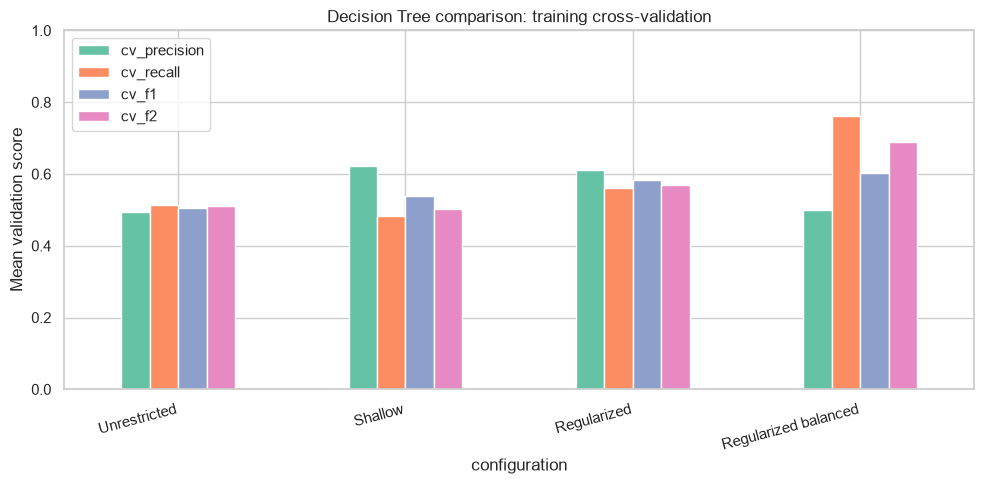

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
}
names = ["Unrestricted", "Shallow", "Regularized", "Regularized balanced"]
candidates = [
    {"model__max_depth": [None], "model__min_samples_leaf": [1], "model__class_weight": [None]},
    {"model__max_depth": [4], "model__min_samples_leaf": [20], "model__class_weight": [None]},
    {"model__max_depth": [6], "model__min_samples_leaf": [20], "model__class_weight": [None]},
    {"model__max_depth": [6], "model__min_samples_leaf": [20], "model__class_weight": ["balanced"]},
]
search = GridSearchCV(make_pipeline(), candidates, scoring=scoring, refit="f2", cv=cv,
                      return_train_score=True, n_jobs=1, error_score="raise")
search.fit(X_train, y_train)
results = pd.DataFrame(search.cv_results_)
comparison = pd.DataFrame({"configuration": names})
for metric in scoring:
    comparison[f"cv_{metric}"] = results[f"mean_test_{metric}"]
comparison["cv_f2_std"] = results["std_test_f2"]
comparison["train_f2"] = results["mean_train_f2"]
comparison["train_validation_f2_gap"] = comparison.train_f2 - comparison.cv_f2
comparison["parameters"] = results.params.astype(str)
display(comparison.sort_values("cv_f2", ascending=False))
comparison.to_csv(REPORTS / "model_comparison.csv", index=False)

# A trivial reference makes misleading accuracy easier to recognize.
dummy_scores = cross_validate(DummyClassifier(strategy="most_frequent"),
                              np.zeros((len(y_train), 1)), y_train, cv=cv, scoring=scoring)
dummy_summary = {m: float(dummy_scores[f"test_{m}"].mean()) for m in scoring}
print("Majority-class baseline CV metrics:", dummy_summary)
selected_name = names[search.best_index_]
final_model = search.best_estimator_  # already refitted on the complete 70% training set
selected = comparison.iloc[search.best_index_]
selection_text = (f"Selected {selected_name}: mean validation F2={selected.cv_f2:.3f} "
                  f"(SD {selected.cv_f2_std:.3f}), recall={selected.cv_recall:.3f}, "
                  f"precision={selected.cv_precision:.3f}. This has the highest mean F2 "
                  "among the specified candidates, matching the stated recall-focused objective. "
                  f"Its training-minus-validation F2 gap is {selected.train_validation_f2_gap:.3f}; "
                  "a large positive gap suggests overfitting. The test set was not used to choose it.")
display(Markdown(selection_text))
print("Selected parameters:", search.best_params_)
(REPORTS / "model_selection.md").write_text(selection_text, encoding="utf-8")
ax = comparison.set_index("configuration")[["cv_precision", "cv_recall", "cv_f1", "cv_f2"]].plot.bar(figsize=(10, 5))
ax.set(ylabel="Mean validation score", ylim=(0, 1), title="Decision Tree comparison: training cross-validation")
plt.xticks(rotation=15, ha="right")
finish("09_model_comparison")

## 7. Final evaluation on the untouched 30% test set
The final fitted training pipeline makes all test predictions. The default classifier decision is retained: pick the class with the larger probability; ties choose No. No threshold is optimized using test outcomes.

,test_score
accuracy,0.734501
precision,0.500000
recall,0.791444
f1,0.612836
f2,0.708812


              precision    recall  f1-score   support

    No churn       0.90      0.71      0.80      1552
       Churn       0.50      0.79      0.61       561

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.80      0.73      0.75      2113



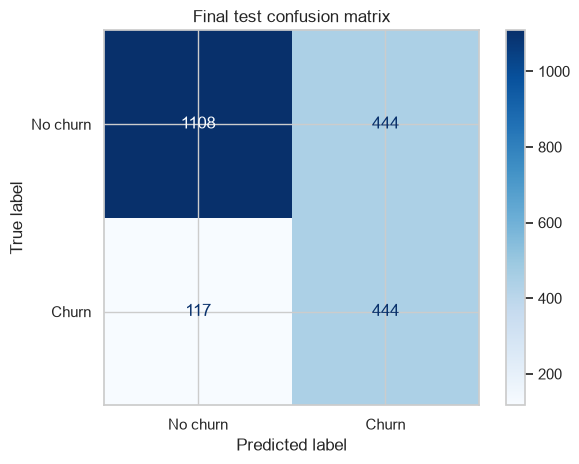

**Business interpretation:** On 2113 held-out customers, the model correctly flagged 444 churners and missed 117. It also flagged 444 customers who did not churn; 1108 non-churners were correctly left unflagged. Recall of 79.1% is the share of actual churners identified. Precision of 50.0% is the share of flagged customers who actually churned. The campaign would contact 888 customers in this test cohort. These are classification outcomes, not proven customers saved or revenue gained.

460

In [14]:
test_pred = final_model.predict(X_test)
metrics = {
    "accuracy": float(accuracy_score(y_test, test_pred)),
    "precision": float(precision_score(y_test, test_pred, zero_division=0)),
    "recall": float(recall_score(y_test, test_pred, zero_division=0)),
    "f1": float(f1_score(y_test, test_pred, zero_division=0)),
    "f2": float(fbeta_score(y_test, test_pred, beta=2, zero_division=0)),
}
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = [int(x) for x in cm.ravel()]
display(pd.Series(metrics, name="test_score").to_frame())
print(classification_report(y_test, test_pred, labels=[0, 1], target_names=["No churn", "Churn"], zero_division=0))
ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(cmap="Blues", values_format="d")
plt.title("Final test confusion matrix")
finish("10_confusion_matrix")
(REPORTS / "test_metrics.json").write_text(json.dumps({**metrics, "confusion_matrix": cm.tolist(),
    "class_order": ["No", "Yes"]}, indent=2), encoding="utf-8")

business_text = (
    f"On {len(y_test)} held-out customers, the model correctly flagged {tp} churners "
    f"and missed {fn}. It also flagged {fp} customers who did not churn; {tn} non-churners were correctly left unflagged. "
    f"Recall of {metrics['recall']:.1%} is the share of actual churners identified. "
    f"Precision of {metrics['precision']:.1%} is the share of flagged customers who actually churned. "
    f"The campaign would contact {tp + fp} customers in this test cohort. "
    "These are classification outcomes, not proven customers saved or revenue gained."
)
display(Markdown("**Business interpretation:** " + business_text))
(REPORTS / "business_interpretation.md").write_text(business_text, encoding="utf-8")

### Precision or recall?
**Prioritize recall when missing a customer who leaves is more costly than an unnecessary outreach.** False negatives mean lost chances to intervene. However, low precision wastes contact capacity and discounts on customers who would stay. If offers are expensive or the campaign is tightly capacity-limited, precision may matter more. F2 represents a transparent provisional compromise; real deployment should use campaign costs, capacity and experimental retention uplift.

Tree probabilities are leaf class proportions. If balanced class weights were selected, they are weighted proportions, so they are **not calibrated real-world churn likelihoods**. Calibration and threshold selection would require training-only validation, followed by a fresh evaluation. Do not tune further using this test set.

## 8. Interpretation: feature importance and Decision Tree
Impurity-based importance shows which encoded features the model uses to reduce node impurity. It has no sign: high importance does not by itself mean higher churn. It can favor features with more possible split points, and correlated predictors can share importance. Read the splits and EDA alongside the importance chart.

,importance
categorical__Contract_Month-to-month,0.568769
numeric__tenure,0.111988
categorical__InternetService_Fiber optic,0.094721
numeric__MonthlyCharges,0.058955
numeric__TotalCharges,0.029947
categorical__OnlineSecurity_No,0.022789
categorical__TechSupport_No,0.020747
categorical__PaymentMethod_Electronic check,0.020295
categorical__InternetService_No,0.015404
categorical__Contract_One year,0.013015


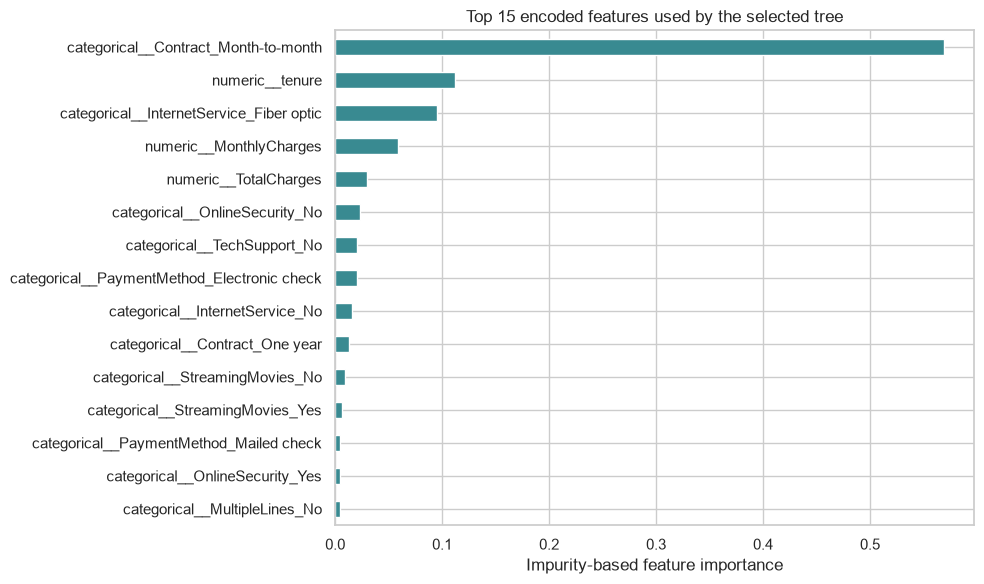

**Key finding:** The leading model inputs are `categorical__Contract_Month-to-month`, `numeric__tenure`, `categorical__InternetService_Fiber optic`, `numeric__MonthlyCharges`, `numeric__TotalCharges`. These describe predictive associations, not causal drivers.

Selected tree depth: 6; leaves: 58


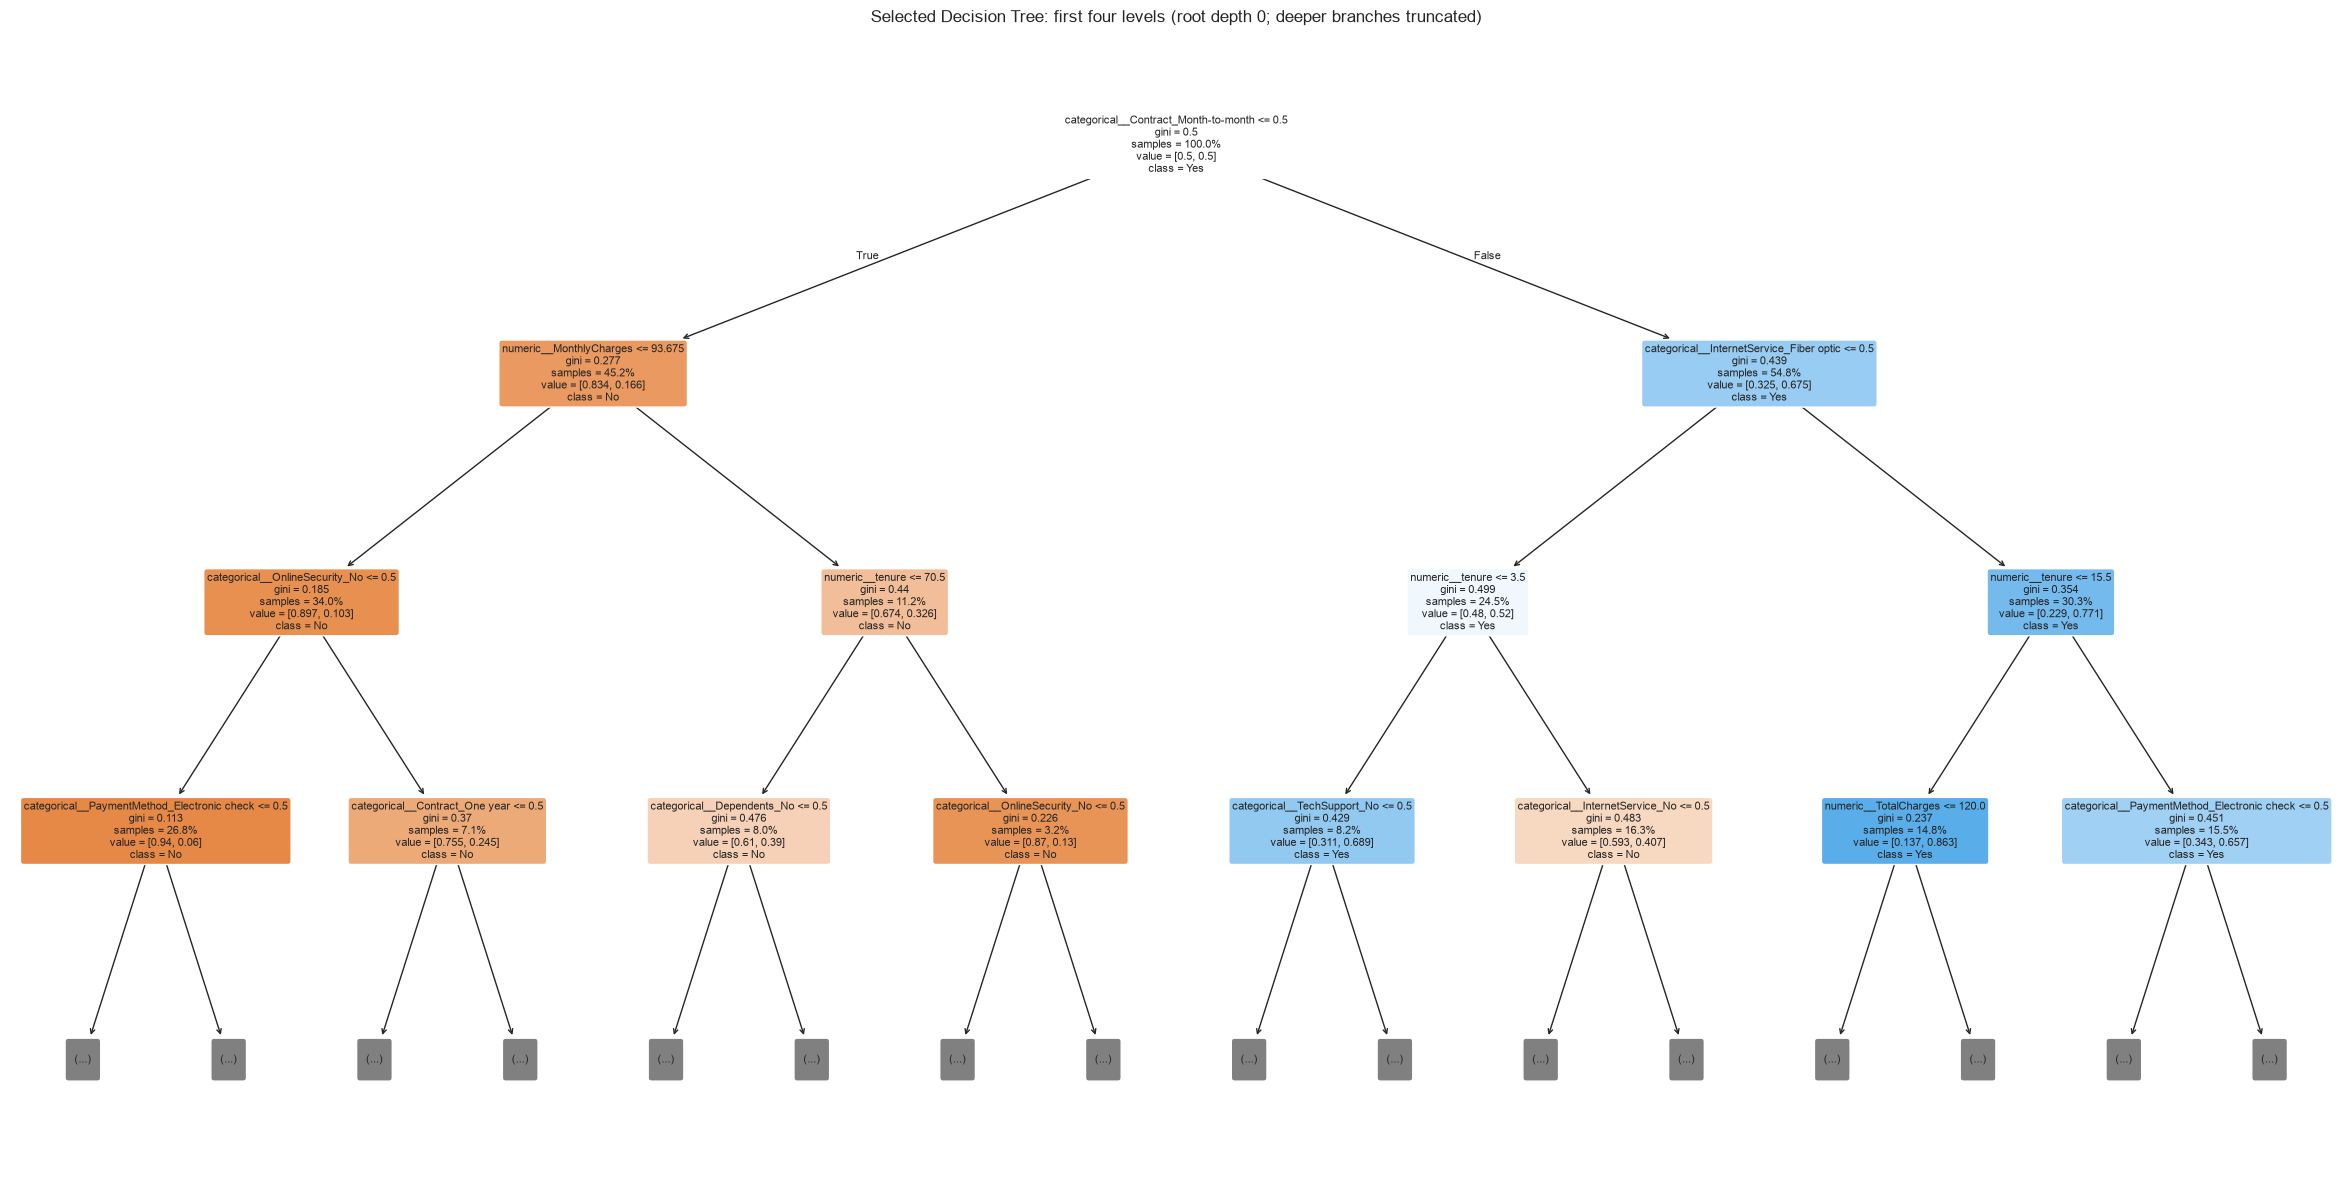

|--- categorical__Contract_Month-to-month <= 0.50
|   |--- numeric__MonthlyCharges <= 93.67
|   |   |--- categorical__OnlineSecurity_No <= 0.50
|   |   |   |--- categorical__PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- numeric__MonthlyCharges <= 70.05
|   |   |   |   |   |--- numeric__tenure <= 59.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- numeric__tenure >  59.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- numeric__MonthlyCharges >  70.05
|   |   |   |   |   |--- categorical__Contract_One year <= 0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- categorical__Contract_One year >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- categorical__PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- categorical__OnlineBackup_No <= 0.50
|   |   |   |   |   |--- categorical__gender_Male <= 0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- categorical__gender_Male >  0.50
|   |   |   |   | 

In [15]:
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
tree = final_model.named_steps["model"]
importance = pd.Series(tree.feature_importances_, index=feature_names, name="importance").sort_values(ascending=False)
importance.to_csv(REPORTS / "feature_importance.csv")
display(importance.head(15).to_frame())
importance.head(15).sort_values().plot.barh(figsize=(10, 6), color="#398a91")
plt.xlabel("Impurity-based feature importance")
plt.title("Top 15 encoded features used by the selected tree")
finish("11_feature_importance")
nonzero = importance[importance > 0]
if len(nonzero):
    display(Markdown("**Key finding:** The leading model inputs are " + ", ".join(f"`{x}`" for x in nonzero.head(5).index) + ". These describe predictive associations, not causal drivers."))
else:
    display(Markdown("**Key finding:** The tree made no splits. The available configuration/data supports only a constant prediction; no feature drivers can be claimed."))
print(f"Selected tree depth: {tree.get_depth()}; leaves: {tree.get_n_leaves()}")
plt.figure(figsize=(24, 12))
plot_tree(tree, feature_names=list(feature_names), class_names=["No", "Yes"],
          max_depth=3, filled=True, rounded=True, fontsize=8, proportion=True)
plt.title("Selected Decision Tree: first four levels (root depth 0; deeper branches truncated)")
finish("12_decision_tree")
rules = export_text(tree, feature_names=list(feature_names), max_depth=100)
(REPORTS / "tree_rules.txt").write_text(rules, encoding="utf-8")
print(rules[:5000])
print("Complete tree rules saved in reports/tree_rules.txt. Class 1 = Churn Yes.")

### Reading the tree and translating findings
Follow a split left when its `<=` condition is true and right otherwise. An encoded value of 1 means the category is present; for example `Contract_Month-to-month <= 0.5` separates customers outside that category from those in it. Numerical thresholds apply after training-derived imputation. Node proportions can be weighted when class balancing is used.

The displayed top splits provide conditional explanations; the importance chart alone does not describe direction. Prioritize a small retention pilot in relevant customer segments and measure incremental impact using a control group. Contract, tenure, service and billing associations can guide hypotheses, but do not prove which intervention will work.

## 9. Save the complete pipeline and sample response
Keep `preprocessing.py` alongside the application: the saved pipeline imports its transformer class. Use the same Python/dependency environment for training and serving. Load only model artifacts you trust because joblib/pickle can execute code.

The saved model is exactly the model evaluated above, trained on 70% of the data. We do not silently retrain it on the test data.

In [16]:
MODEL_PATH = ROOT / "model/churn_model.pkl"
joblib.dump(final_model, MODEL_PATH)
loaded = joblib.load(MODEL_PATH)
np.testing.assert_array_equal(loaded.predict(X_test), test_pred)
np.testing.assert_allclose(loaded.predict_proba(X_test), final_model.predict_proba(X_test))

sample = json.loads((ROOT / "sample_request.json").read_text(encoding="utf-8"))
sample_response = prediction_result(loaded, sample)
(ROOT / "sample_response.json").write_text(json.dumps(sample_response, indent=2) + "\n", encoding="utf-8")
print("Saved pipeline:", MODEL_PATH)
print("Actual model response for sample_request.json:")
print(json.dumps(sample_response, indent=2))

packages = ["numpy", "pandas", "scikit-learn", "matplotlib", "seaborn", "joblib", "fastapi", "pydantic", "uvicorn", "jupyterlab", "ipykernel", "nbconvert"]
installed = {}
for package in packages:
    try:
        installed[package] = version(package)
    except Exception:
        installed[package] = "not installed"
metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(), "python": platform.python_version(),
    "dataset_filename": DATA_PATH.name, "dataset_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "raw_rows": len(raw), "deduplicated_rows": len(data), "train_rows": len(train), "test_rows": len(test),
    "random_state": SEED, "test_size": 0.30, "cv_folds": 5, "selection_metric": "F2",
    "selected_configuration": selected_name, "parameters": search.best_params_,
    "selected_cv_f2": float(search.best_score_), "test_metrics": metrics,
    "dummy_cv_metrics": dummy_summary, "versions": installed,
}
(REPORTS / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
(REPORTS / "requirements_used.txt").write_text("\n".join(f"{p}=={v}" for p, v in installed.items() if v != "not installed") + "\n", encoding="utf-8")
print("Reload verification passed. Figures, metrics, insights and environment versions are in reports/.")

Saved pipeline: C:\DocX\NAGP\customer_churn_project\customer_churn_project\model\churn_model.pkl
Actual model response for sample_request.json:
{
  "prediction": "Yes",
  "churn_probability": 0.869657
}


Reload verification passed. Figures, metrics, insights and environment versions are in reports/.


## 10. Run and verify the REST API
From the project root, in a terminal using the same environment:

```bash
python -m uvicorn app:app --reload
```

Open http://127.0.0.1:8000/docs and use **POST /predict → Try it out** with `sample_request.json`.

In a second terminal:

```bash
python test_api.py
```

This sends a real HTTP request, saves the actual response to `sample_response.json`, and checks that three invalid requests receive HTTP 422. All predictor keys are required; `customerID` is optional and ignored by the model. `null` is accepted for missing predictor values; malformed numbers, invalid categories, missing keys and extra fields are rejected. A blank `TotalCharges` string is treated as missing. Category spelling follows the sample/data dictionary.

The server loads the saved pipeline once at startup. If the model is missing, startup fails with an instruction to run this notebook first.

## 11. Conclusions, limitations and submission checklist
Review the generated `model_selection.md`, `business_interpretation.md`, EDA insights, feature importance and tree rules. Explain the actual results in your own words if asked during review.

Limitations: this is a historical, random-split evaluation rather than a temporal deployment study; future churn prediction requires confirming feature availability at scoring time and defining a prediction horizon. Generalization to other populations, probability calibration, campaign benefit and subgroup performance have not been established. Service-count/tenure-group improvement has not been isolated via ablation. No financial savings are claimed.

Before submission:
- [ ] Run all cells successfully on the supplied customer dataset.
- [ ] Check quality reports and read every generated chart insight.
- [ ] Save this notebook **with outputs**.
- [ ] Include `app.py`, `preprocessing.py`, `test_api.py`, `requirements.txt` and `README.md`.
- [ ] Include generated `model/churn_model.pkl` and `reports/`.
- [ ] Start FastAPI and run `test_api.py`.
- [ ] Include `sample_request.json` and the generated `sample_response.json`.
- [ ] Include the dataset only if the submission instructions allow it; exclude your virtual environment and caches.

Implementation references: [scikit-learn: avoiding leakage](https://scikit-learn.org/stable/common_pitfalls.html), [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html), [FastAPI request bodies](https://fastapi.tiangolo.com/tutorial/body/).